# Process Model Creation and Validation
Discover, refine, and evaluate a process model from the BPIC-17 event log that satisfies the four quality dimensions (fitness, precision, generalization, simplicity):

1. Apply at least two different process discovery algorithms and add the resulting process models in the appendix.

2. Compute all relevant PM4Py quality metrics. In addition, implement at least two simplicity metrics yourself in Python [1]. Report the result on all discovered process models.

3. Construct a final process model by combining insights from the discovery algorithms, existing reports, domain knowledge, and the simple event log analysis. Refine the model iteratively and explain your design decisions step by step. The model should replay approximately 80% of the cases while maintaining high precision, generalization, and simplicity. Discuss the rationale behind your modeling decisions and the limitations of the resulting model. Describe the trade-offs between the quality metrics, justify which metrics you prioritized, and explain why these are appropriate given that the model serves as a base model for simulation. Provide the resulting BPMN 2.0 process model in the report, along with the values for all quality metrics.

4. Perform data-aware process mining, also known as decision mining [2]. For each XOR in your final process model, add a decision block. Follow the instructions and approach of the paper. Find a way to visualize the BPMN in your report, including the decision blocks at the XOR gateways.

References: 

[1] Josep Carmona, Boudewijn F. van Dongen, Andreas Solti, and Matthias Weidlich. *Conformance Checking - Relating Processes and Models*. Springer, 2018.

[2] Massimiliano de Leoni and Wil M. P. van der Aalst. Data-aware process mining: discovering decisions in processes using alignments. In *Proceedings of the 28th Annual ACM Symposium on Applied Computing, SAC '13, Coimbra, Portugal, March 18-22, 2013*, pages 1454–1461. ACM, 2013.

- import libraries:

In [19]:
import pm4py # process mining library
import pandas as pd # data manipulation library
import os # operating system library for file handling
import matplotlib.pyplot as plt # plotting library for visualizations
import numpy as np # numerical computing library for data analysis
import networkx as nx # library for graph analysis and visualization

- load only completed and relabled events 

In [6]:
df = pd.read_csv("../data/renamed_log.csv", low_memory=False)
df['time:timestamp'] = pd.to_datetime(df['time:timestamp'], format='mixed', utc=True)
event_log = pm4py.format_dataframe(df, case_id='case:concept:name', activity_key='concept:name', timestamp_key='time:timestamp')


### Define own Simplicity metrics

In the book [3], the following metrics are mentioned as candidates for simplicity metrics by analyzing the complexity of the underlying graph:
- Size
- Diameter
- Density
- Connectivity
- Node Degree

Given that the graph functions as a process model, additional domain-specific metrics can be applied:

- Sequentiality: Gateway arcs divided by total arcs.
- Structuredness: Proportion of reducible, well-structured parts in the model.
- Depth: Average or max depth of split/join constructs.
- Gateway Mismatch: Difference between input and output arcs for connected gateways.
- Gateway Heterogeneity: Entropy of gateway types used.
- Control Flow Complexity: Sum of choices based on split types and outgoing arcs.
- Cyclicity: Ratio of nodes in cycles to total nodes.
- Token Splits: Number of concurrent threads from AND/OR-splits.


[3] Josep Carmona, Boudewijn F. van Dongen, Andreas Solti, and Matthias Weidlich. *Conformance Checking - Relating Processes and Models*. Springer, 2018, pp. 223–224.

- a first simple simplicity metrics is the size (arcs and nodes) that is implemented in the following way:

In [17]:
def calculate_node_size(net):
    """
    Calculates the total number of nodes in a pm4py Petri net.
    Nodes = Places + Transitions
    """
    num_places = len(net.places)
    num_transitions = len(net.transitions)
    
    return num_places + num_transitions

def calculate_arc_size(net):
    """
    Calculates the total number of arcs (edges) in a pm4py Petri net.
    """
    return len(net.arcs)

- another metric that makes sense in general is the cyclicity of the net
- implementation:

In [20]:
def calculate_cyclicity(net):
    """
    Calculates the cyclicity of a pm4py Petri net.
    Cyclicity = (number of nodes within cycles) / (total number of nodes)
    
    :param net: pm4py Petri net object
    :return: Float representing the cyclicity metric (between 0.0 and 1.0)
    """
    # 1. Calculate total number of nodes (Places + Transitions)
    total_nodes = len(net.places) + len(net.transitions)
    
    if total_nodes == 0:
        return 0.0
        
    # 2. Build a NetworkX Directed Graph
    G = nx.DiGraph()
    
    # Add all places and transitions as nodes
    for place in net.places:
        G.add_node(place)
    for transition in net.transitions:
        G.add_node(transition)
        
    # Add all arcs as directed edges
    for arc in net.arcs:
        G.add_edge(arc.source, arc.target)
        
    # 3. Identify nodes in cycles
    # A node is in a cycle if it is part of a Strongly Connected Component (SCC)
    # with more than 1 node, or if it is a single node with a self-loop.
    nodes_in_cycles = set()
    
    for scc in nx.strongly_connected_components(G):
        if len(scc) > 1:
            # All nodes in an SCC of size > 1 are part of a cycle
            nodes_in_cycles.update(scc)
        elif len(scc) == 1:
            # Check for self-loops for single-node components
            node = list(scc)[0]
            if G.has_edge(node, node):
                nodes_in_cycles.add(node)
                
    # 4. Calculate the cyclicity ratio
    cyclicity = len(nodes_in_cycles) / total_nodes
    
    return cyclicity

### process discovery 

- inductive Miner

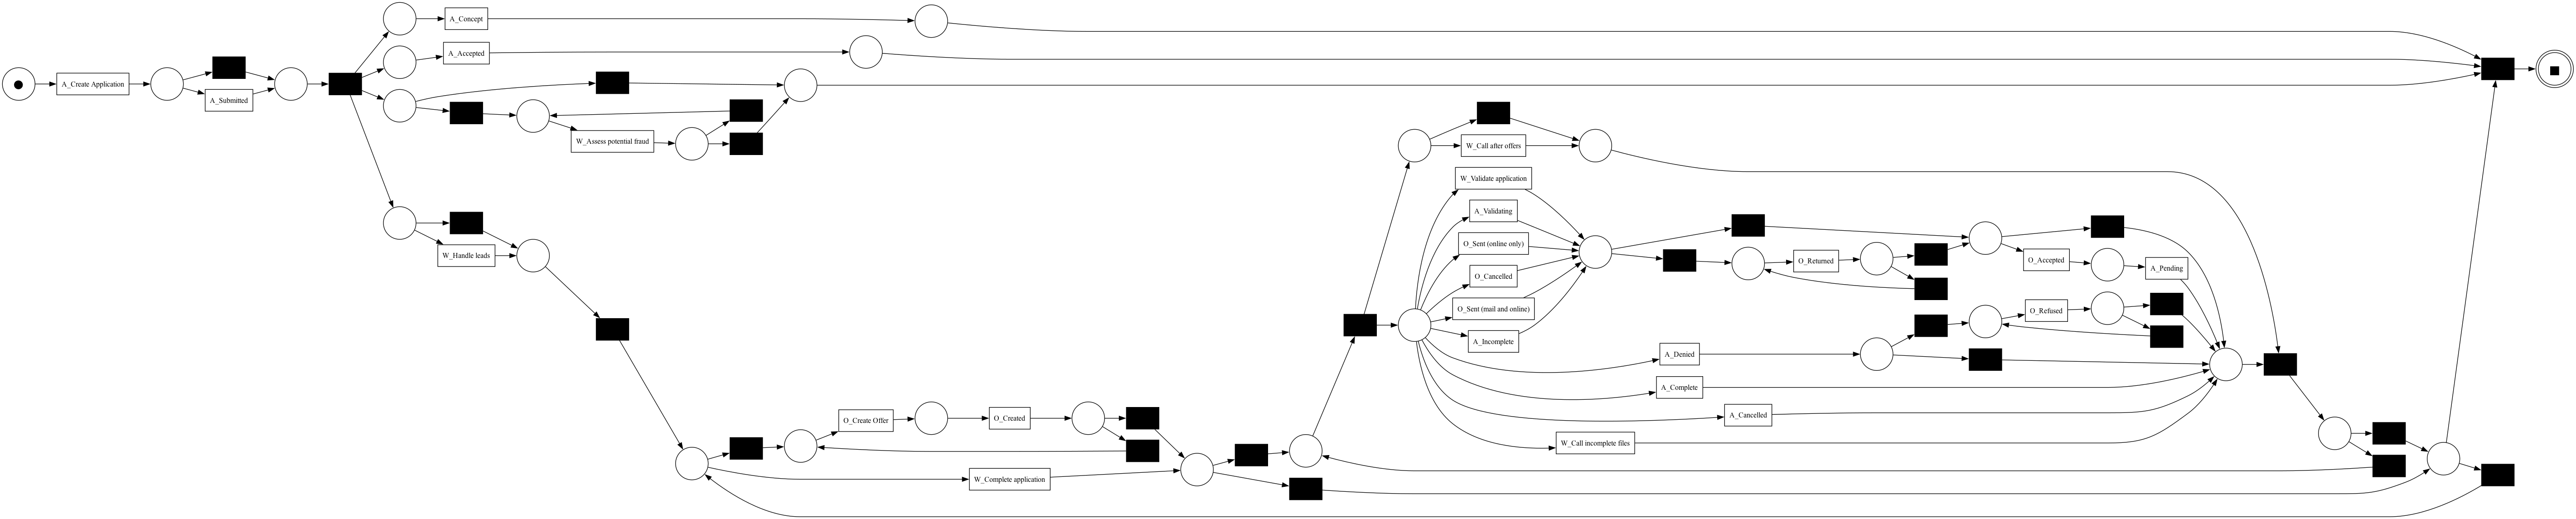

In [ ]:
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(event_log)
pm4py.view_petri_net(net, initial_marking, final_marking)


- calculate conformance metrics

In [16]:
generalization_all = pm4py.algo.evaluation.generalization.variants.token_based.apply(event_log, net, initial_marking, final_marking)
precision_all = pm4py.algo.evaluation.precision.variants.etconformance_token.apply(event_log, net, initial_marking, final_marking)
fitness_all = pm4py.algo.evaluation.replay_fitness.variants.token_replay.apply(event_log, net, initial_marking, final_marking)
print(f"Generalization: {generalization_all:.4f}")
print(f"Precision: {precision_all:.4f}")
print(f"Fitness: {fitness_all}")

replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27816 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

Generalization: 0.9757
Precision: 0.2926
Fitness: {'perc_fit_traces': 100.0, 'average_trace_fitness': 1.0, 'log_fitness': 1.0, 'percentage_of_fitting_traces': 100.0}


- calculate simplicity

In [21]:
node_size_all = calculate_node_size(net)
arc_size_all = calculate_arc_size(net)
cyclicity_all = calculate_cyclicity(net)
print(f"Node Size: {node_size_all}")
print(f"Arc Size: {arc_size_all}")
print(f"Cyclicity: {cyclicity_all:.4f}")

Node Size: 87
Arc Size: 114
Cyclicity: 0.7126


- store the petri net in the correct directory

In [8]:
# Define the target directory and file name for saving the Petri net visualization
target_dir = "../petrinets/basic"
file_name = "petri_net_inductive.pdf"
full_path = os.path.join(target_dir, file_name)

# create target directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# Save the Petri net visualization to a file
pm4py.save_vis_petri_net(net, initial_marking, final_marking, full_path)

''